<a href="https://colab.research.google.com/github/cynpardede/PCD/blob/main/Pertemuan10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving dede.png to dede.png


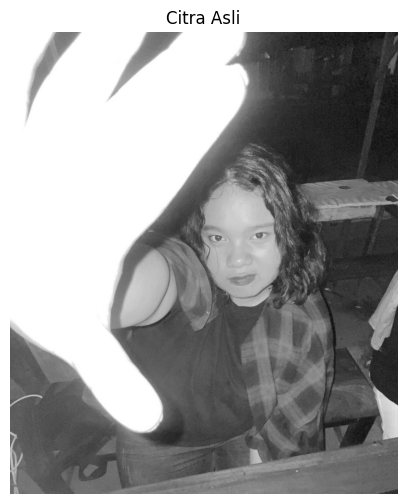

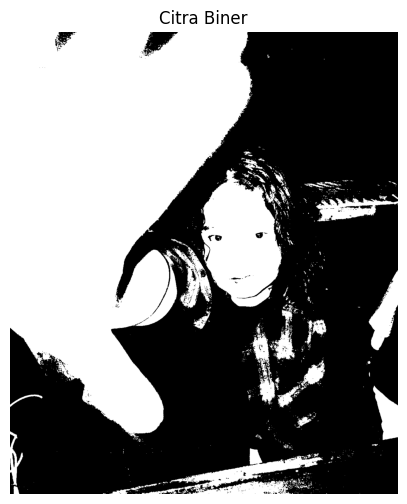

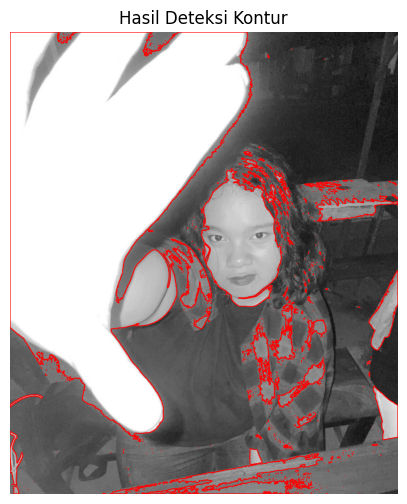


Objek 1
Luas      : 0.0
Perimeter : 2.0
Centroid  : (0, 0)

Objek 2
Luas      : 0.0
Perimeter : 0.0
Centroid  : (0, 0)

Objek 3
Luas      : 0.0
Perimeter : 0.0
Centroid  : (0, 0)

Objek 4
Luas      : 0.0
Perimeter : 4.0
Centroid  : (0, 0)

Objek 5
Luas      : 0.0
Perimeter : 2.0
Centroid  : (0, 0)

Objek 6
Luas      : 0.0
Perimeter : 0.0
Centroid  : (0, 0)

Objek 7
Luas      : 1.5
Perimeter : 5.414213538169861
Centroid  : (1093, 1598)

Objek 8
Luas      : 0.0
Perimeter : 2.0
Centroid  : (0, 0)

Objek 9
Luas      : 0.0
Perimeter : 2.0
Centroid  : (0, 0)

Objek 10
Luas      : 3.0
Perimeter : 8.828427076339722
Centroid  : (554, 1598)

Objek 11
Luas      : 1.0
Perimeter : 4.828427076339722
Centroid  : (438, 1598)

Objek 12
Luas      : 0.5
Perimeter : 5.414213538169861
Centroid  : (329, 1598)

Objek 13
Luas      : 0.0
Perimeter : 2.0
Centroid  : (0, 0)

Objek 14
Luas      : 0.0
Perimeter : 2.0
Centroid  : (0, 0)

Objek 15
Luas      : 5.5
Perimeter : 9.41421353816986
Centroid  : (975, 1598)

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar grayscale
image = cv2.imread("dede.png", cv2.IMREAD_GRAYSCALE)

# Menampilkan citra asli
plt.figure(figsize=(8,6))
plt.title("Citra Asli")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

# ==========================
# Thresholding
# ==========================

_, binary_image = cv2.threshold(
    image,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(8,6))
plt.title("Citra Biner")
plt.imshow(binary_image, cmap='gray')
plt.axis('off')
plt.show()

# ==========================
# Deteksi Kontur
# ==========================

contours, hierarchy = cv2.findContours(
    binary_image,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Menggambar kontur
output_image = cv2.cvtColor(
    image,
    cv2.COLOR_GRAY2RGB
)

cv2.drawContours(
    output_image,
    contours,
    -1,
    (255,0,0),
    2
)

plt.figure(figsize=(8,6))
plt.title("Hasil Deteksi Kontur")
plt.imshow(output_image)
plt.axis('off')
plt.show()

# ==========================
# Ekstraksi Fitur Geometri
# ==========================

for i, contour in enumerate(contours):

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(
        contour,
        True
    )

    moments = cv2.moments(contour)

    if moments["m00"] != 0:
        cx = int(moments["m10"] / moments["m00"])
        cy = int(moments["m01"] / moments["m00"])
    else:
        cx = 0
        cy = 0

    print(f"\nObjek {i+1}")
    print(f"Luas      : {area}")
    print(f"Perimeter : {perimeter}")
    print(f"Centroid  : ({cx}, {cy})")

print("\nPraktikum 10 berhasil dijalankan")